# CECS 427 — Assignment 3  
## Positive & Negative Relationships

**Submission:** upload this notebook (`.ipynb`) with code + short written answers.

### Conventions (signed graphs)
- Each edge has a sign stored as an edge attribute: `sign = +1` (positive) or `sign = -1` (negative).
- Unless stated otherwise, graphs are **undirected**.


In [1]:
# Imports / setup
import networkx as nx
import matplotlib.pyplot as plt
import numpy as np
from itertools import combinations
from collections import deque


## Below are the variables used in assignment :

- `n`: number of nodes (size of the graph).
- `p_pos`: probability an edge is **positive** (`sign = +1`) when generating random signed graphs.
- `sign`: edge attribute; `+1` = positive edge, `-1` = negative edge.
- `a, b, c`: three distinct nodes used to represent a triangle.
- `trials`: number of random graphs simulated for an estimate (larger → smoother results).
- `p_values`: list/array of probabilities to test (e.g., 0.0, 0.1, …, 1.0).
- `color`: dictionary mapping a node → 0/1 label during bipartite checking (two “sides”).
- `X, Y`: sets of nodes representing the 2-group partition when a graph is balanced.
- `groups`: list of sets (used for weak balance partitions into k groups).
- `witness` / `certificate`: a small counterexample explaining why a condition fails.

## Part A — Triangle Balance in Signed Complete Graphs

A signed **complete graph** is balanced when **every triangle** is balanced.

In this assignment, treat a triangle as balanced if it has an **odd** number of positive edges:
- `+++`  (3 positive edges), or
- `+--`  (exactly 1 positive edge)

### Tasks

**A1 — Build & visualize one signed complete graph**
1. Values for `n` and `p_pos` are provided.
2. A signed complete graph `K_n` with an edge attribute `sign ∈ {+1, -1}` is generated.
3. Draw the graph so that **positive** and **negative** edges are clearly distinguishable (e.g., different colors; solid vs dashed).

**A2 — Triangle balance**
1. Implement `is_triangle_balanced(G, a, b, c)`.
2. Compute the **fraction of balanced triangles** in your graph.
3. Print: total triangles, balanced triangles, and the fraction.

**A3 — Simulation + plot (detailed)**
1. Choose a fixed `n` (e.g., 12) and a list of probabilities `p_values` (e.g., 0.0, 0.1, …, 1.0).
2. For each `p_pos` in `p_values`, generate **many** random signed complete graphs (`trials`, e.g., 30).
3. For each graph:
   - enumerate all triangles `(a,b,c)`,
   - compute the fraction that are balanced.
4. For each `p_pos`, compute the **mean** fraction (and optionally the **std** across trials).
5. Plot: x-axis = `p_pos`, y-axis = mean fraction of balanced triangles (label everything clearly).
6. Write a short interpretation (4–6 sentences) in the interpretation box below.


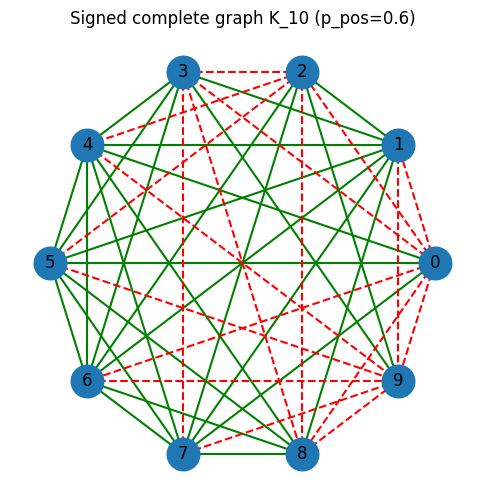

In [2]:
# A1 — Random signed complete graph + visualization

def make_signed_complete_graph(n, p_pos=0.5, seed=None):
    """Return K_n with each edge labeled sign=+1 with prob p_pos, else sign=-1."""
    rng = np.random.default_rng(seed)
    G = nx.complete_graph(n)
    for u, v in G.edges():
        G.edges[u, v]["sign"] = 1 if rng.random() < p_pos else -1
    return G

n = 10
p_pos = 0.6
G = make_signed_complete_graph(n, p_pos=p_pos, seed=7)

pos = nx.circular_layout(G)
pos_edges = [(u, v) for u, v in G.edges() if G.edges[u, v]["sign"] == 1]
neg_edges = [(u, v) for u, v in G.edges() if G.edges[u, v]["sign"] == -1]

plt.figure(figsize=(6, 6))
nx.draw_networkx_nodes(G, pos, node_size=550)
nx.draw_networkx_labels(G, pos)

# Postive edges will be SOLID and GREEN
# Negative edges will be DASHED and RED
# We will save these values if we need to use them later
edge_colors = {1: 'green', -1: 'red'}
edge_styles = {1: 'solid', -1: 'dashed'}

# Draw positive edges
nx.draw_networkx_edges(G, pos, edgelist=pos_edges, edge_color=edge_colors[1], style=edge_styles[1], width=1.5)

# Draw negative edges
nx.draw_networkx_edges(G, pos, edgelist=neg_edges, edge_color=edge_colors[-1], style=edge_styles[-1], width=1.5)

plt.title(f"Signed complete graph K_{n} (p_pos={p_pos})")
plt.axis("off")
plt.show()


In [3]:
# A2 — Triangle balance + fraction of balanced triangles

def triangle_signs(G, a, b, c):
    """Return the 3 edge signs for triangle (a,b,c) as a list."""
    return [G.edges[a, b]["sign"], G.edges[a, c]["sign"], G.edges[b, c]["sign"]]

def is_triangle_balanced(G, a, b, c):
    """Return True iff triangle (a,b,c) has an odd number of + edges."""
    signs = triangle_signs(G, a, b, c)

    # Get the number of positive edges in the triangle
    positive_edges = sum(sign == 1 for sign in signs)

    # Return true if the % 2 == 1, meaning it is odd
    return positive_edges % 2 == 1

# Store list of triangles for simpler calculation below
triangles = list(combinations(G.nodes(), 3))

# Compute the fraction of balanced triangles
total_triangles = len(triangles)
balanced_triangles = sum(is_triangle_balanced(G, *triangle) for triangle in triangles)
p_balanced = balanced_triangles / total_triangles

print("Total triangles:", total_triangles)
print("Balanced triangles:", balanced_triangles)
print("Fraction balanced:", p_balanced)


Total triangles: 120
Balanced triangles: 74
Fraction balanced: 0.6166666666666667


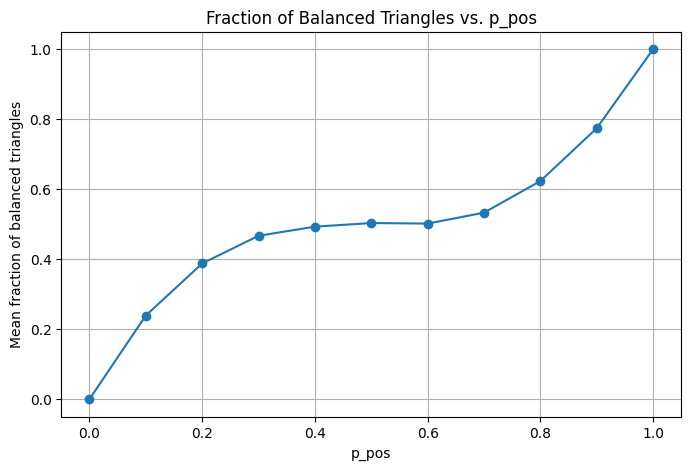

In [4]:
# A3 — Simulation plot: fraction balanced vs p_pos

def fraction_balanced_triangles(n, p_pos, trials=20, seed=0):
    """Estimate how often triangles are balanced in random signed complete graphs.

    Parameters
    ----------
    n : int
        Number of nodes in K_n.
    p_pos : float
        Probability an edge is positive (+1).
    trials : int
        How many random graphs to sample.
    seed : int
        Random seed for reproducibility.

    Returns
    -------
    mean_frac : float
        Mean fraction of balanced triangles across trials.
    std_frac : float
        Standard deviation across trials which helps show variability.
    """
    # TODO (suggested steps):
    # 1) Create a random number generator with the given seed.
    # 2) Repeat 'trials' times:
    #    - build a signed complete graph using make_signed_complete_graph(n, p_pos, seed=...)
    #    - compute fraction balanced triangles (reuse is_triangle_balanced)
    #    - store the fraction
    # 3) Return (mean, std) of the stored fractions.

    # Fraction balanced triangles
    list_fractions = []

    # Random number with the given seed
    rng = np.random.default_rng(seed)

    # Repeat trials times
    for trial in range(trials):
        # Generate a different seed for this trial
        graph_seed = rng.integers(0, 1000000)

        # Build signed complete graph
        graph = make_signed_complete_graph(n, p_pos, seed=graph_seed)

        # Compute the fraction of balanced triangles
        triangles = list(combinations(graph.nodes(), 3))
        total_triangles = len(triangles)
        balanced_triangles = sum(is_triangle_balanced(graph, *triangle) for triangle in triangles)
        p_balanced = balanced_triangles / total_triangles
        list_fractions.append(p_balanced)

    # Return mean and standard deviation of stored fractions
    return np.mean(list_fractions), np.std(list_fractions)

# Choose a fixed n for the experiment
n = 12

# p_values is the list of p_pos values we will test (0.0, 0.1, ..., 1.0)
p_values = np.linspace(0, 1, 11)

# Lists to store means and stds
means = []
stds = []

# For each p in p_values, compute (mean, std) using fraction_balanced_triangles(...)
for p in p_values:
    mean, std = fraction_balanced_triangles(n, p, trials=30, seed=0)
    means.append(mean)
    stds.append(std)

# Plot p_values vs means
plt.figure(figsize=(8, 5))
plt.plot(p_values, means, marker='o')
plt.xlabel("p_pos")
plt.ylabel("Mean fraction of balanced triangles")
plt.title("Fraction of Balanced Triangles vs. p_pos")
plt.grid()
plt.show()


**A3 Interpretation :**  
Describe how the fraction of balanced triangles changes as `p_pos` goes from 0 to 1, and why.


---
## Part B — Balance Theorem vs. Weak Balance (Complete Graphs)

### Tasks

**B1 (Balance check):** Determine whether the graph is balanced under the **two-faction** theorem.  
If balanced, return the partition `(X, Y)`. If not, return a **small witness** showing what rule fails.

**B2 (Weak balance check):** Determine whether the graph is weakly balanced (may allow `k ≥ 1` groups).  
If weakly balanced, return a list of groups. If not, return a **witness triangle** that violates the rule.

**B3 (Experiment + plot — detailed):**
1. For each `p_pos` in a list (e.g., 0.0 to 1.0), generate many random signed complete graphs.
2. Estimate:
   - `pb[p]` = fraction of graphs that are **balanced**
   - `pw[p]` = fraction of graphs that are **weakly balanced**
3. Plot both curves on the same axes with a legend and clear labels.
4. Write a short interpretation (5–8 sentences) below explaining the difference.

In [17]:
# B1 — Balance checker (2 groups)
from itertools import combinations

def is_balanced_complete(G):
    """Check the 2-group balance theorem condition for a signed complete graph.

    Returns:
      (True, (X, Y), None)  if balanced with partition (X, Y)
      (False, None, witness) otherwise
    """

    # Pick a starting node
    start = next(iter(G.nodes))

    # Set X and Y, add start node to X
    X = [start]
    Y = []

    # Add remainding nodes to set X and Y depend on its sign
    for neighbor in G.neighbors(start):
      edge_sign = G[start][neighbor]["sign"]
      if edge_sign == 1: X.append(neighbor)
      else: Y.append(neighbor)

    # Make a dictionary of each node and its faction for easy look up
    faction = {node: "X" for node in X}
    faction.update({node: "Y" for node in Y})

    for u,v in combinations(G.nodes, 2):
      actual_sign = G[u][v]["sign"]
      expected_sign = 1 if faction[u] == faction[v] else -1 # if 2 nodes are in the same faction then it should have positive sign
                                                            # else the sign should be negative
      if actual_sign != expected_sign:
        return False, None, (start, u, v)

    return True, (X,Y), None


In [18]:
# B1 - Tests
# TODO: test on:
# 1) a balanced example you construct by hand (two groups)
# 2) a graph that is not balanced

def test_balanced_complete_graph():
    G = nx.Graph()
    G.add_nodes_from([0, 1, 2, 3])

    # Two factions: {0, 1} and {2, 3}.
    # Positive within factions; negative between them.
    G.add_edges_from([
        (0, 1, {"sign":  1}),
        (2, 3, {"sign":  1}),
        (0, 2, {"sign": -1}),
        (0, 3, {"sign": -1}),
        (1, 2, {"sign": -1}),
        (1, 3, {"sign": -1}),
    ])

    balanced, partition, witness = is_balanced_complete(G)

    assert balanced is True
    assert witness is None

    X, Y = map(set, partition)
    assert X.isdisjoint(Y)
    assert X | Y == set(G.nodes)

    # Confirm every edge agrees with the returned partition.
    faction = {node: "X" for node in X}
    faction.update({node: "Y" for node in Y})

    for u, v in G.edges:
        expected = 1 if faction[u] == faction[v] else -1
        assert G[u][v]["sign"] == expected


def test_unbalanced_complete_graph():
    G = nx.Graph()
    G.add_nodes_from([0, 1, 2])

    # This triangle has one negative edge, so it is unbalanced.
    G.add_edges_from([
        (0, 1, {"sign":  1}),
        (0, 2, {"sign":  1}),
        (1, 2, {"sign": -1}),
    ])

    balanced, partition, witness = is_balanced_complete(G)

    assert balanced is False
    assert partition is None
    assert witness is not None

    # Confirm the witness is a triangle with an odd number of negative edges.
    a, b, c = witness
    triangle_signs = [
        G[a][b]["sign"],
        G[b][c]["sign"],
        G[c][a]["sign"],
    ]
    assert sum(sign == -1 for sign in triangle_signs) % 2 == 1

test_balanced_complete_graph()
test_unbalanced_complete_graph()

In [7]:
# B2 — Weak balance checker (k groups)

def is_weakly_balanced_complete(G):
    """Return whether the signed complete graph is weakly balanced.

    Returns:
      (True, groups, None) if weakly balanced, where groups is list[set]
      (False, None, witness_triangle) otherwise
    """
    # TODO
    pass

# TODO: test on:
# 1) weakly balanced but not balanced example (should produce k > 2 groups)
# 2) not weakly balanced example (should return a witness triangle)


In [8]:
# B3 — Empirical comparison: balanced vs weakly balanced vs
# TODO (what to produce):
# 1) Call estimate_probabilities(...) with your chosen n and trials.
#    - n: number of nodes in the complete graph K_n
#    - trials: how many random graphs per p_pos
# 2) Plot:
#    - p_values vs pb (balanced probability)
#    - p_values vs pw (weakly balanced probability)
# 3) Add axis labels, title, and legend.

def estimate_probabilities(n=10, trials=200, seed=0):
    rng = np.random.default_rng(seed)
    p_values = np.linspace(0, 1, 11)
    pb, pw = [], []
    for p in p_values:
        bal_count = 0
        weak_count = 0
        for _ in range(trials):
            Gt = make_signed_complete_graph(n, p_pos=p, seed=int(rng.integers(0, 10**9)))
            is_bal, _, _ = is_balanced_complete(Gt)
            is_w, _, _ = is_weakly_balanced_complete(Gt)
            bal_count += int(is_bal)
            weak_count += int(is_w)
        pb.append(bal_count / trials)
        pw.append(weak_count / trials)
    return p_values, pb, pw



**B3 Interpretation :**  
Explain why weak balance is typically easier to satisfy than balance, and how the allowed structure differs.


---
## Part C — Structural Balance for General (Non-Complete) Signed Graphs

For general signed graphs, we will use the reduction idea from lecture:

1) Build the **positive-edge subgraph** and take its connected components (**supernodes**).  
2) Check whether any negative edge occurs inside a positive supernode. If so, the graph is immediately not balanced.  
3) Build a **reduced graph** whose nodes are supernodes; add an edge between two supernodes if there is a **negative** edge between them in the original graph.  
4) If there is no internal negative edge, the original signed graph is balanced iff the reduced graph is **bipartite**.

### Tasks

**C1.** Build and draw the three provided signed graphs (make + vs − edges visually distinct).

**C2.** Implement `supernode_reduction(G)` and print:
- the supernodes (positive components),
- any negative edges that occur *inside* a supernode,
- the reduced graph edges.

Also draw the reduced graph.

**C3.** Implement `bfs_bipartite(reduced_G, start)` **from scratch** and use it to decide whether each graph is balanced:

1. If a negative edge occurs inside a positive supernode, report the graph as not balanced.
2. Otherwise, test whether the reduced graph is bipartite using BFS.
3. If the reduced graph is bipartite, return the induced 2-way partition `(X, Y)` of original nodes.
4. If not bipartite, return a small certificate such as an edge connecting two same-colored supernodes.

The three graphs are designed to illustrate different cases:
- **G1:** balanced, with a non-trivial even cycle in the reduced graph,
- **G2:** not balanced because the reduced graph contains an odd cycle,
- **G3:** not balanced because a negative edge occurs inside a positive supernode.

In [9]:
# C1 — Build + draw three signed graphs

def make_signed_graph(edge_list):
    """
    edge_list: list of (u, v, sign) where sign is +1 or -1.
    Return a NetworkX Graph with edge attribute: sign.
    """
    # TODO: implement
    pass


def draw_signed_graph(G, title=""):
    """
    Draw G with different styles for positive vs negative edges.
    - Use a solid line for + edges
    - Use a dashed line for - edges
    """
    # TODO: implement
    pass


# G1:
edges1 = [
    (1, 2,   1),
    (3, 4,   1),
    (5, 6,   1),
    (7, 8,   1),
    (9, 10,  1),
    (11, 12, 1),
    (1, 7,   -1),
    (8, 3,   -1),
    (4, 11,  -1),
    (12, 5,  -1),
    (6, 9,   -1),
    (10, 2,  -1),
]


# G2:
edges2 = [
    (1, 2,   1),
    (3, 4,   1),
    (5, 6,   1),
    (7, 8,   1),
    (9, 10,  1),
    (11, 12, 1),
    (1, 7,   -1),
    (8, 3,   -1),
    (4, 11,  -1),
    (12, 5,  -1),
    (6, 1,   -1),
    (2, 9,   -1),
]


# G3:
edges3 = [
    (1, 2,  1),
    (2, 3,  1),
    (1, 3, -1),
    (4, 5,  1),
    (6, 7,  1),
    (3, 4, -1),
    (5, 6, -1),
]


# TODO: build G1, G2, and G3

# TODO: print a short summary for each graph:
# - number of nodes, number of edges
# - number of positive edges, number of negative edges

# TODO: draw all three graphs

In [10]:
# C2 — Supernode reduction + reduced graph

def supernode_reduction(G):
    """Return:
      supernodes: list[set]   (positive-edge connected components)
      node_to_super: dict[node] -> int
      reduced_graph: nx.Graph (supernodes connected by negative edges)
      internal_negative_edges: list of negative edges inside a positive component
    """
    # TODO
    return supernodes, node_to_super, reduced_G, internal_negative_edges


# TODO: run reduction for G1, G2, and G3 and print:
# - supernodes
# - internal negative edges
# - reduced graph edges
#
# Also draw each reduced graph.

In [11]:
# C3 — BFS bipartite test from scratch + balance decision

from collections import deque

def bfs_bipartite(reduced_G, start):
    """BFS-based bipartite check (implement from scratch).

    Parameters
    ----------
    reduced_G : nx.Graph
        Reduced graph (nodes = supernodes, edges = negative ties between supernodes).
    start : hashable
        Starting node for BFS in one connected component.

    Returns
    -------
    is_bipartite : bool
        True if this component can be 2-colored.
    color : dict
        Mapping node -> 0 or 1 (the BFS side).
    conflict_edge : tuple or None
        If not bipartite, return an edge (u, v) with the same color on both ends.
    """
    # TODO (suggested steps):
    # 1) Initialize color[start] = 0 and a queue with start.
    # 2) Pop u; for each neighbor v:
    #    - if v is uncolored, set color[v] = 1 - color[u] and enqueue
    #    - else if color[v] == color[u], return (False, color, (u,v))
    # 3) If BFS finishes, return (True, color, None)
    pass


def is_balanced_general_signed_graph(G):
    """Decide balance using supernode reduction + bipartite test.

    Returns:
      (True, (X, Y), None) if balanced
      (False, None, certificate) if not balanced

    certificate should be a short explanation
    (e.g., internal negative edge, or conflict edge).
    """
    # TODO (suggested steps):
    # 1) Run supernode_reduction(G).
    # 2) If there is a negative edge inside a positive supernode,
    #    immediately return not balanced.
    # 3) The reduced graph may be disconnected:
    #    - run bfs_bipartite on each component
    #    - if any component is not bipartite, return not balanced
    #      with its conflict edge.
    # 4) If bipartite, translate supernode colors into a partition
    #    (X, Y) of original nodes.
    pass


# TODO:
# - Call is_balanced_general_signed_graph on G1, G2, and G3
# - Print whether each graph is balanced
# - If balanced, print X and Y
# - If not balanced, print the certificate

### Conceptual Questions (Answer in Markdown)

1. Why does the triangle rule in complete graphs create a global “two factions (or all friends)” structure?  
2. What changes when we go from **balance** to **weak balance**?  
3. For general graphs: explain why an **odd number of negative edges on a cycle** signals “imbalance.”


---
## Part D — Approximately Balanced Networks

### Tasks

**D1 (Approximate balance theorem):** Suppose 99.9% of all triangles in a complete signed graph are balanced.  
1. Compute `epsilon` where `1 - epsilon = 0.999`.
2. Compute `delta = epsilon**(1/3)`.
3. Compute `1 - delta`.
4. Briefly explain what `1 - delta` means in terms of the approximate global structure of the graph.

**D2 (Good node + approximate partition):**  
The **weight** of a node is the number of unbalanced triangles containing that node.
1. Compute the weight of every node.
2. Find a node with minimum weight and call it the **good node** `A`.
3. Use `A` to form two sets:
   - `X` = `A` and all positive neighbors of `A`
   - `Y` = all negative neighbors of `A`
4. Count the edges that violate the expected balanced structure:
   - negative edges inside `X`
   - negative edges inside `Y`
   - positive edges between `X` and `Y`
5. Report the fraction of wrong-sign edges.


In [12]:
# D1 — Approximate balance theorem

balanced_fraction = 0.999

# TODO:
# 1) Compute epsilon from balanced_fraction
# 2) Compute delta = epsilon ** (1/3)
# 3) Compute 1 - delta

epsilon = "TODO"
delta = "TODO"
approx_fraction = "TODO"

print("epsilon:", epsilon)
print("delta:", delta)
print("Approximate global fraction:", approx_fraction)


epsilon: TODO
delta: TODO
Approximate global fraction: TODO


**D1 Interpretation :**  
Explain what the value `1 - delta` says about the approximate global structure when 99.9% of all triangles are balanced.


In [13]:
# D2 — Good node + approximate partition

def node_unbalanced_weights(G):
    """Return a dictionary mapping each node to the number of
    unbalanced triangles containing that node.
    """
    # TODO
    pass


def find_good_node(G):
    """Return the node with minimum unbalanced-triangle weight
    and its weight.
    """
    # TODO
    pass


def good_node_partition(G, A):
    """Use good node A to form:
      X = A and all positive neighbors of A
      Y = all negative neighbors of A
    """
    # TODO
    pass


def wrong_sign_fraction(G, X, Y):
    """Count edges that violate the expected balanced structure:
      - negative edges inside X
      - negative edges inside Y
      - positive edges between X and Y

    Return:
      wrong_edges, total_edges, fraction_wrong
    """
    # TODO
    pass


# TODO:
# 1) Generate or reuse a signed complete graph
# 2) Find the good node A
# 3) Build X and Y
# 4) Compute the wrong-sign edge fraction
# 5) Print the results


**D2 Interpretation :**  
Explain why a graph can be approximately balanced even if some triangles and edges violate perfect structural balance. Relate your explanation to the good node and the partition `(X, Y)`.
